# 146. LRU 缓存

请你设计并实现一个满足  LRU (最近最少使用) 缓存 约束的数据结构。

实现 LRUCache 类：

LRUCache(int capacity) 以 正整数 作为容量 capacity 初始化 LRU 缓存

int get(int key) 如果关键字 key 存在于缓存中，则返回关键字的值，否则返回 -1 。

void put(int key, int value) 如果关键字 key 已经存在，则变更其数据值 value ；如果不存在，则向缓存中插入该组 key-value 。如果插入操作导致关键字数量超过 capacity ，则应该 逐出 最久未使用的关键字。

函数 get 和 put 必须以 O(1) 的平均时间复杂度运行。

## 解题思路

1. get 和 put 时间复杂度 O(1)，那么很快想到可以用字典做，空间换时间。
2. 当关键字数量超过容量时，要删除最久未使用的关键字，因此涉及到一个元素顺序维护的问题。

最终方案：使用 collections 库里的 OrderedDict 类。

自带有添加删除元素、移到最后的操作，并且 python 官方文档里也有使用其实现 LRU 的例子。

这个类我们平时用的比较少，所以可以使用 dir、help函数获取用法。（这是一个很关键的技巧！！）

- dir() 会返回一个列表，包含该对象所有的属性和方法名
  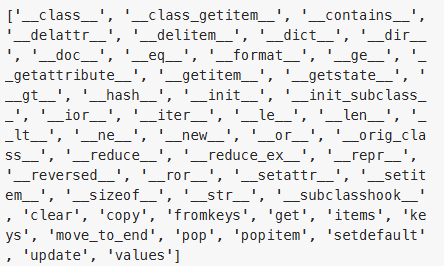
- help() 会打印出该类的详细说明文档
  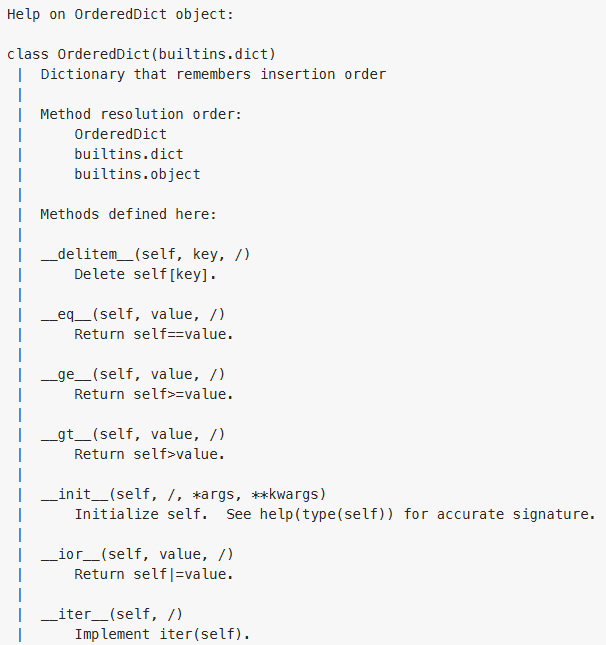

In [ ]:
class LRUCache:

    def __init__(self, capacity: int):
        import collections
        self.capacity = capacity
        self.cache = OrderedDict()
        

    def get(self, key: int) -> int:
        if key not in self.cache:
            return -1
        self.cache.move_to_end(key, last=True)
        return self.cache[key]
        

    def put(self, key: int, value: int) -> None:
        self.cache[key] = value
        self.cache.move_to_end(key, last=True)
        if len(self.cache) > self.capacity:
            self.cache.popitem(last=False)
        


# Your LRUCache object will be instantiated and called as such:
# obj = LRUCache(capacity)
# param_1 = obj.get(key)
# obj.put(key,value)